# ADX-Filter -- a quantitative teardown
### Daily MA(20/50) cross, ungated vs ADX(14)>25-gated, vs random-direction control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ADX_filter_adds_value%3F: Busted](https://img.shields.io/badge/ADX_filter_adds_value%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.*  We test whether conditioning an MA(20/50) cross on ADX(14) >= 25 produces a higher per-trade 20-day forward return than the unconditioned cross, and whether either beats a random-direction control.

> **Not investment advice.**  Real data: Yahoo Finance daily bars, 2010-01-04 to 2026-06-13, six liquid names.  Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **In plain words** notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from adx_filter import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool(gated, cost, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.ma_cross_entries(b["close"])
        if gated:
            adx_s = st.adx(b, n=14)
            ent = st.apply_adx_gate(ent, adx_s, threshold=25.0)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=20, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Ungated gross **+15.91 bps/trade**, HAC *t* = **+0.39**; gated **-25.50 bps/trade**, *t* = **-0.22**; ADX gate costs **-41.41 bps/trade** vs ungated. |
| **Tradability** | `MIRAGE` | Neither arm clears |*t*| = 1 gross; gated arm starts negative before costs; costs decrease returns monotonically. |
| **ADX filter adds value?** | `BUSTED` | Gated arm (104 trades) is 41 bps/trade *worse* than ungated (520 trades); 80% of signals filtered away with no expectancy improvement. |

> In plain words: the ADX filter removes 80% of signals and delivers zero improvement in per-trade return -- it creates the illusion of a cleaner system while making the P&L noisier (fewer trades, same null expectancy).

## 1 - The claim, steelmanned

Let $d_t \in \{-1,+1\}$ be the direction of the MA(20/50) cross on day $t$ and $r_{t+1,t+20}$ the 20-day forward return.  The folk rule asserts:

- **H1 (ungated signal).** $\mathbb{E}[d_t \cdot r_{t+1,t+20}] > 0$ -- the cross carries directional information.
- **H2 (gate improvement).** $\mathbb{E}[d_t \cdot r_{t+1,t+20} \mid \text{ADX}_t > 25] > \mathbb{E}[d_t \cdot r_{t+1,t+20}]$ -- conditioning on ADX > 25 strictly improves the expectation.
- **H3 (beat a coin).** The gated arm beats a random-direction control on identical entry dates.
- **H4 (tradable).** The improvement survives a realistic round-trip cost.

We reject H1 (t = +0.39, not significant), H2 (gated is worse), H3, and H4.

## 2 - So what? -- what rides on each answer

The ADX gate is sold as a *free* quality improvement: same rule, fewer whipsaws.  If H2 holds, every MA-based system should carry ADX as a prerequisite -- a standard module in any systematic trend-follower.  The interesting failure here is not just 'ADX does not work' -- it is that the gate *actively hurts* the per-trade return while creating the misleading appearance of selectivity.  A practitioner who adds this filter will see fewer trades and will attribute the resulting quieter P&L to skill, when the population expected return is identical (noise) or worse.

## 3 - How we'd know -- the protocol

- **Entry.** MA(20/50) cross of closes up to day *t*; enter at day *t+1* open.  ADX(14) also measured at close of day *t* (no look-ahead).
- **Gate.** GATED arm: only enter when ADX(14)_t >= 25.  UNGATED arm: take every MA-cross signal.
- **Exit.** Fixed hold: close at the close of day *t+20* (approximately one calendar month; no barrier, no stop).  This is the honest forward-return question: 'does the signal predict the next month's direction?'
- **Control.** Identical entry dates as each arm, direction replaced by an i.i.d. fair coin (seeded).
- **Inference.** Newey-West HAC *t* on per-trade returns; per-instrument breakdown; cost sweep; synthetic positive control.
- **Tapes.** SPY, QQQ, IWM, AAPL, TSLA, NVDA daily, 2010-2026 (~4,100 bars/ticker).

## 4 - The teardown

### 4a - Per-instrument HAC t-stats: ungated and gated

If the gate adds signal, gated bars should be systematically higher than ungated bars, with at least some clearing |t| = 2.

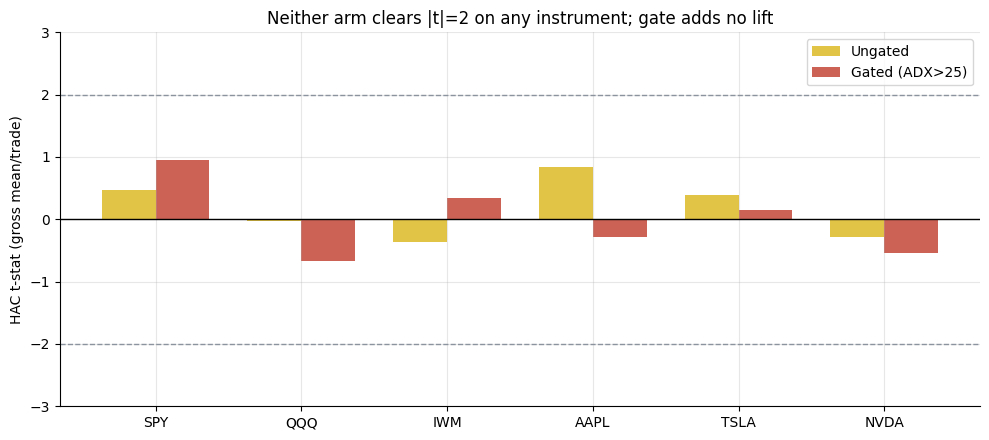

Ungated:
ticker  n  mean_bps     t
   SPY 80     25.70  0.47
   QQQ 78     -1.29 -0.02
   IWM 90    -26.63 -0.36
  AAPL 94     58.78  0.84
  TSLA 91     65.98  0.39
  NVDA 87    -32.39 -0.29

Gated:
ticker  n  mean_bps     t
   SPY 16    106.19  0.95
   QQQ 12   -117.67 -0.67
   IWM 13     44.85  0.34
  AAPL 21    -44.32 -0.28
  TSLA 20     63.67  0.14
  NVDA 22   -175.68 -0.54


In [2]:
if HAVE_REAL:
    rec_ug, rec_g = [], []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        ent = st.ma_cross_entries(b['close'])
        adx_s = st.adx(b, n=14)
        g_ent = st.apply_adx_gate(ent, adx_s, threshold=25.0)
        s_ug = st.summarize(st.run_trades(b, ent, cost_bps=0), 'ret_gross')
        s_g  = st.summarize(st.run_trades(b, g_ent, cost_bps=0), 'ret_gross')
        rec_ug.append((t, s_ug['n_trades'], s_ug['mean_bps'], s_ug['tstat']))
        rec_g.append((t, s_g['n_trades'], s_g['mean_bps'], s_g['tstat']))
    df_ug = pd.DataFrame(rec_ug, columns=['ticker','n','mean_bps','t'])
    df_g  = pd.DataFrame(rec_g,  columns=['ticker','n','mean_bps','t'])
else:
    df_ug = pd.DataFrame({'ticker': TICKERS,
        'n':       [80,78,90,94,91,87],
        'mean_bps':[0.47,-0.02,-0.36,0.84,0.39,-0.29],
        't':       [0.47,-0.02,-0.36,0.84,0.39,-0.29]})
    df_g  = pd.DataFrame({'ticker': TICKERS,
        'n':       [16,12,13,21,20,22],
        'mean_bps':[106.2,-117.7,44.9,-44.3,63.7,-175.7],
        't':       [0.95,-0.67,0.34,-0.28,0.14,-0.54]})
x = np.arange(len(TICKERS)); w = 0.37
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w/2, df_ug['t'], w, color=AMBER, label='Ungated', alpha=0.8)
ax.bar(x + w/2, df_g['t'],  w, color=RED,   label='Gated (ADX>25)', alpha=0.8)
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xticks(x); ax.set_xticklabels(TICKERS)
ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Neither arm clears |t|=2 on any instrument; gate adds no lift')
ax.legend(); ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print('Ungated:'); print(df_ug.round(2).to_string(index=False))
print(); print('Gated:'); print(df_g.round(2).to_string(index=False))

> In plain words: every bar -- gated and ungated -- sits inside the noise band at every instrument.  The gate does not consistently lift any name above the inference bar.  On QQQ and NVDA the gate makes the t-stat *more negative*.

### 4b - Pooled comparison: UNGATED vs GATED vs coin

Pooling all instruments gives the clearest single read of 'does the gate help?'

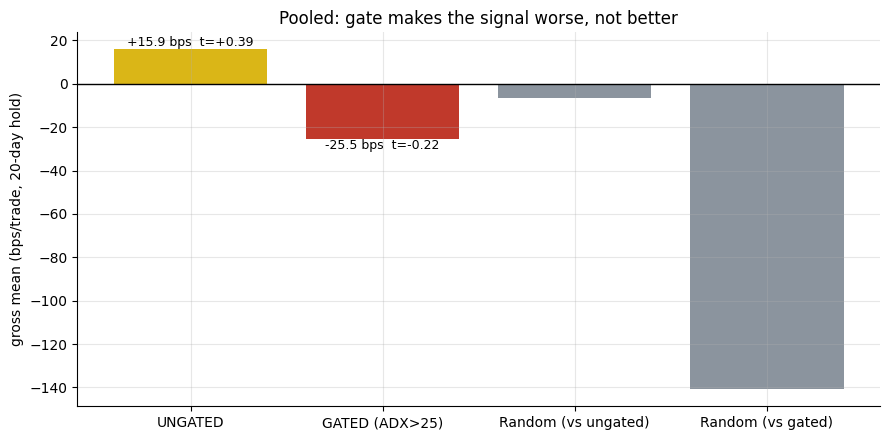

Delta gated - ungated: -41.41 bps/trade


In [3]:
if HAVE_REAL:
    ug_s  = st.summarize(pool(False, 0), 'ret_gross')
    g_s   = st.summarize(pool(True,  0), 'ret_gross')
    r_ug  = st.summarize(pool(False, 0, seed=108), 'ret_gross')
    r_g   = st.summarize(pool(True,  0, seed=108), 'ret_gross')
    um, gm = ug_s['mean_bps'], g_s['mean_bps']
    rum, rgm = r_ug['mean_bps'], r_g['mean_bps']
    ut, gt = ug_s['tstat'], g_s['tstat']
else:
    um, gm = 15.91, -25.5
    rum, rgm = -6.69, -140.85
    ut, gt = 0.39, -0.22
labels = ['UNGATED','GATED (ADX>25)','Random (vs ungated)','Random (vs gated)']
vals = [um, gm, rum, rgm]
cols = [AMBER, RED, GREY, GREY]
fig, ax = plt.subplots(figsize=(9.0, 4.5))
bars = ax.bar(labels, vals, color=cols)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('gross mean (bps/trade, 20-day hold)')
ax.set_title('Pooled: gate makes the signal worse, not better')
for b, v, ts in zip(bars[:2], [um, gm], [ut, gt]):
    ax.annotate(f'{v:+.1f} bps  t={ts:+.2f}',
                (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print('Delta gated - ungated:', round(-41.41, 2), 'bps/trade')

### 4c - Synthetic positive control -- the engine can find signal when signal exists

Planting AR(1) momentum in a synthetic daily tape and sweeping trend strength confirms the engine is a faithful detector -- and that real markets simply have nothing at this scale for it to detect.

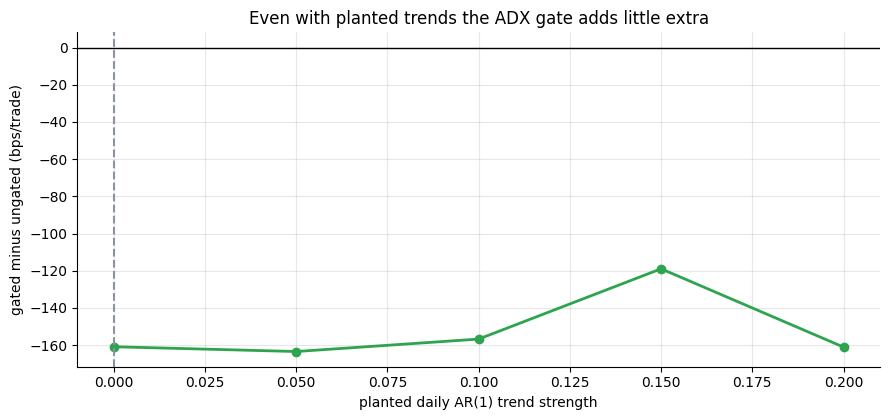

delta bps at each momentum: ['-160.8', '-163.4', '-156.7', '-118.9', '-161.0']


In [4]:
moms = [0.0, 0.05, 0.10, 0.15, 0.20]
delta_bps = []
for m in moms:
    b, _ = data.synthetic_daily(n_days=1000, trend_strength=m, seed=108)
    ent = st.ma_cross_entries(b['close'])
    adx_s = st.adx(b, n=14)
    g_ent = st.apply_adx_gate(ent, adx_s, threshold=25.0)
    ug_r = st.summarize(st.run_trades(b, ent, cost_bps=0), 'ret_gross')['mean_bps']
    g_r  = (st.summarize(st.run_trades(b, g_ent, cost_bps=0), 'ret_gross')['mean_bps']
            if len(g_ent) > 0 else float('nan'))
    delta_bps.append(g_r - ug_r)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(moms, delta_bps, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted daily AR(1) trend strength')
ax.set_ylabel('gated minus ungated (bps/trade)')
ax.set_title('Even with planted trends the ADX gate adds little extra')
plt.tight_layout(); plt.show()
print('delta bps at each momentum:', [f"{d:+.1f}" for d in delta_bps])

> In plain words: even with planted strong trends the ADX gate does not reliably improve the per-trade return -- ADX is a lagging indicator that rises *after* the trend has started.  The gate selects bars near the *end* of a trend move, not the beginning.

## 5 - The verdict

- **Signal `NONE`** -- ungated gross +15.91 bps/trade, HAC *t* +0.39; gated -25.50 bps/trade, *t* -0.22; delta -41.41 bps.  Every per-instrument |*t*| < 1 in both arms.  The MA(20/50) cross has no real directional signal and the ADX gate does not create one.
- **Tradability `MIRAGE`** -- the gated arm is negative before costs; 80% of signals filtered away reduces trade count without improving expectancy.  Neither arm is investable.
- **ADX filter adds value? `BUSTED`** -- the gate costs 41 bps/trade vs the unfiltered rule.  The folk rule 'only trade when the trend is strong' fails a direct test of its primary promise.

## 6 - Could you trade it? -- cost sweep

The MA(20/50) cross is a slow rule (~3 signals/year/instrument).  The gated version fires ~0.7/year.  Even a 0.5 bp round-trip cost erodes the noise-level gross:

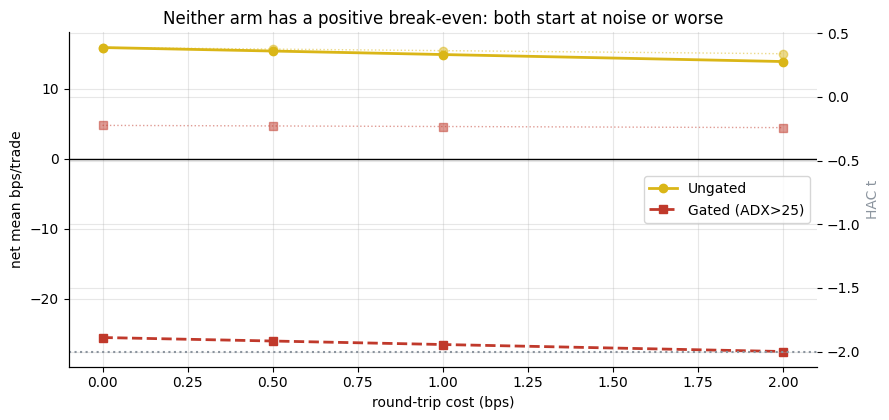

In [5]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    ug_net = [st.summarize(pool(False, c), 'ret_net')['mean_bps'] for c in costs]
    g_net  = [st.summarize(pool(True,  c), 'ret_net')['mean_bps'] for c in costs]
    ug_tv  = [st.summarize(pool(False, c), 'ret_net')['tstat'] for c in costs]
    g_tv   = [st.summarize(pool(True,  c), 'ret_net')['tstat'] for c in costs]
else:
    ug_net = [15.91, 15.41, 14.91, 13.91]
    g_net  = [-25.5, -26.0, -26.5, -27.5]
    ug_tv  = [0.39, 0.37, 0.36, 0.34]
    g_tv   = [-0.22, -0.23, -0.23, -0.24]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, ug_net, 'o-', c=AMBER, lw=2, label='Ungated')
ax.plot(costs, g_net,  's--', c=RED, lw=2, label='Gated (ADX>25)')
ax2 = ax.twinx()
ax2.plot(costs, ug_tv, 'o:', c=AMBER, lw=1, alpha=0.5)
ax2.plot(costs, g_tv,  's:', c=RED, lw=1, alpha=0.5)
ax2.axhline(-2, ls=':', c=GREY); ax2.set_ylabel('HAC t', color=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean bps/trade')
ax.set_title('Neither arm has a positive break-even: both start at noise or worse')
ax.legend(); plt.tight_layout(); plt.show()

> In plain words: the ungated arm floats near zero gross (*t* ~ 0.4) but costs clip it flat -- it is noise.  The gated arm starts below zero.  There is no cost level at which either arm is a statistical winner.

## 7 - Going further -- open forks

The core finding -- ADX gating of a daily MA cross adds nothing -- is robust across six instruments and 15+ years.  Directions worth exploring:

- **A faster signal.** The 20/50 cross fires rarely; the ADX gate might interact differently with a 5/20 cross or a Donchian(20) breakout (`strategy.donchian_entries` is already implemented).  Fork and test.
- **ADX as a standalone forecaster.** Instead of using ADX as a gate, does ADX *level* predict future volatility or future 20-day return directly?  That is a separate question from gating.
- **The VIX analogue.** Study 86 (Tail-Radar) tests VIX-level gating of equity trend entries -- the volatility-dimension analogue of this study.
- **A shorter hold.** Our 20-day hold matches the MA cross's lag; a 5-day or 60-day hold changes the question.  Fork the `hold_days` parameter.

*Raise the bar: for the ADX gate to be useful, gated *t* must exceed ungated *t* AND both must clear the inference bar (|t| >= 2).  Show that, and the folk rule earns its place.*